# Exercícios de Regressão Logística e Classificação Binária

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$


### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$


### c) Classificação final

- Se $\hat{y} > 0.5$  Classe 1  
- Caso contrário  Classe 0  



## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$?  
2. Qual o papel do $b$?  
3. Por que usamos a função sigmoide?

Dica:

- $w$ →  importância de cada variável  
- $b$ →  ajuste da linha  
- Sigmoide →  transforma em probabilidade  

#EX 1

A predição encontrada pelo modelo no exercicio 1 foi da funcao (y_pred = 2.0*x1 + -1.0*x2 + 0.5) pois encontrou w1=2.0, w2= -1.0 e b=0.5.

A predição é gerada através do treinamento do modelo com x e y de treinamento e ele tenta adivinhar em cima de um X_Test quais seriam os valores que mais condizem com a função original para classificar algo. <br>
Os pesos demonstram qual a "importancia" de cada coluna das entradas, ou seja a importancia da feature(caracteristica) de cada X.<br>

Já o viés (bias) funciona como um ajuste de posição (intercepto), deslocando essa fronteira no espaço para que ela não precise obrigatoriamente passar pela origem (0,0); ele não desloca os eixos X e Y individualmente, mas sim o valor base do cálculo.

a) No exemplo do ponto x_1=1.2 e x_2=-0.3, o valor resultante z = 3.2 representa o score de classificação. Na prática, esse número indica de qual lado da fronteira o ponto está: se z é positivo, o modelo classifica o ponto como uma classe; se for negativo, como a outra. A magnitude desse valor mostra o quão longe o ponto está da 'linha de incerteza', servindo como uma medida de confiança da predição.


<br>b) Ja a probabilidade y = 1/(1+e^(-z)) é aproximadamente 0.961, que representa que o modelo tem 96% de certeza que aquele ponto é da classe 1, pois esta bem acima do limiar de decisão, que é ali no 0.5.

# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

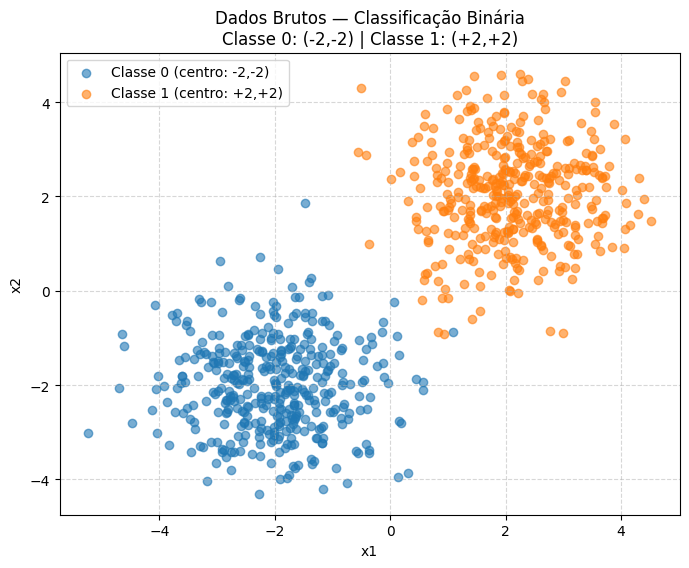

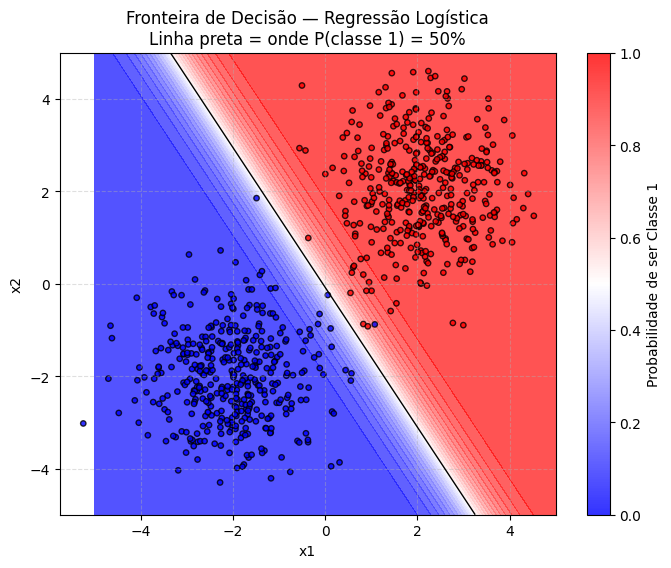


Coeficientes aprendidos:
w1 = 2.526  (peso de x1)
w2 = 1.669  (peso de x2)
b  = 0.123   (bias/intercepto)

Fronteira: 2.53*x1 + 1.67*x2 + 0.12 = 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

#Define uma semente padrão para garantir a reprodutibilidade dos testes, utilizando sempre os mesmos parametros aleatorios toda vez que rodar
np.random.seed(42)


# Quantidade de amostras que cada classe vai gerar
# Classe 0 com 400 amostras
# Classe 1 com 400 amostras
# Total de 800 amostras
N = 400

# Classe 0

# np.random.randn(N, 2)
# Gera N=400 linhas e 2 colunas de números aleatórios
# Distribuição Normal (curva de sino):
#     Média = 0
#     Desvio padrão = 1
# Shape resultante: (400, 2)

# - 2
# Subtrai 2 de TODOS os valores
# DESLOCA o centro do grupo para (-2, -2)
# Sem isso, o centro seria (0, 0)
# Com isso, o centro fica em (-2, -2)

# Resultado final de x0:
# 400 pontos espalhados ao redor de (-2, -2)

# Cada coluna representam as features(caracteristicas) contidas nos dados de entrada

x0 = np.random.randn(N, 2) - 2
y0 = np.zeros(N) #Cria um vetor de 0 da mesma quantidade de amostras, representa a classificação da CLASSE 0

# Classe 1

# Mesma lógica da classe 0, mas:
# + 2 (em vez de - 2)
# Desloca o centro para (+2, +2) em vez de (-2, -2)
# As duas classes ficam em lados opostos do gráfico

x1 = np.random.randn(N,2) +2
y1 = np.ones(N) # Representa a classificação da CLASSE 1

# Juntar dados

# np.vstack([x1,x2])
# Irá concatenar as matrizes de forma vertical ('v'.stack)
# Primeiras 400 linhas = pontos da classe 0
# Últimas  400 linhas  = pontos da classe 1
# Shape final: (800,2)


# np.hstack([y0,y1])
# Irá concatenar os vetores de forma horizontal ('h'.stack)
# Primeiras 400 posições ([0,399]) = label(classificação) classe 0
# Últimas 400 posições ([400, 799]) = label(classificação) classe 1

X = np.vstack([x0, x1])
Y = np.hstack([y0, y1])

# Separar treino e teste


# train_test_split(X, Y, test_size=0.3, random_state=42)

# Divide os dados em dois grupos:
#     Treino: o modelo VAI VER esses dados para aprender
#     Teste:  o modelo NUNCA VÊ esses dados durante treino
#                   Usamos só para avaliar se aprendeu bem

# Por que separar?
# Se treinar e testar com os MESMOS dados:
#     O modelo "decora" as respostas (overfitting)
#     Parece ótimo, mas falha com dados novos

# Parâmetros:
# X  - Features (800 pontos, 2 colunas)
# Y  - Rótulos  (800 valores: 0 ou 1)
# test_size=0.3 - 30% dos dados vão para TESTE
#                 70% dos dados vão para TREINO
#                 800 * 0.30 = 240 pontos de teste
#                 800 * 0.70 = 560 pontos de treino
# random_state=42 - Pega amostras de forma aleatoria porém reprodutivel

# Retorna 4 arrays:
# X_train - Features de treino  shape: (560, 2)
# X_test  - Features de teste   shape: (240, 2)
# y_train - Rótulos de treino   shape: (560,)
# y_test  - Rótulos de teste    shape: (240,)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42
)

# Treinar modelo

# LogisticRegression()
# Cria o modelo (ainda vazio, não aprendeu nada)
# É um classificador que:
#     1. Calcula z = w1*x1 + w2*x2 + b
#     2. Aplica Sigmoid: P = 1 / (1 + e^(-z))
#     3. Se P >= 0.5 - prediz classe 1
#        Se P  < 0.5 - prediz classe 0

# model.fit(X_train, y_train)
# TREINA o modelo com os dados de treino
# Internamente ajusta os pesos w1, w2 e b
#   para minimizar os erros de classificação
# Só usa X_train e y_train (nunca vê X_test)

modelo = LogisticRegression()
modelo.fit(X_train, y_train) # Treina o modelo

# Predição

# model.predict(X_test)
# Usa os 240 pontos de TESTE para avaliar o modelo
# Para cada ponto, calcula P e decide 0 ou 1
# Retorna array de predições: [0, 1, 1, 0, ...]
# Shape: (240,)

# Depois poderia comparar y_pred com y_test:
# Acertos = onde y_pred == y_test
# Erros = onde y_pred != y_test

y_pred = modelo.predict(X_test)

# Plot dos dados

# plt.figure(figsize=(8, 6))
# Cria uma janela/canvas para o gráfico
# figsize=(8,6): 8 polegadas de largura, 6 de altura

plt.figure(figsize=(8, 6))

# plt.scatter(x0[:,0], x0[:,1], ...)
# Plota os pontos da CLASSE 0

# x0[:,0]
# x0 tem shape (400, 2)
# [:,0] = TODAS as linhas, coluna 0
# São os valores de x1 (eixo horizontal)
# Resultado: array de 400 valores

# x0[:,1]
# [:,1] = TODAS as linhas, coluna 1
# São os valores de x2 (eixo vertical)
# Resultado: array de 400 valores

# alpha=0.6
# 60% opaco (40% transparente)
# Ajuda a ver sobreposições de pontos
# Regiões densas ficam mais escuras

# label="Classe 0"
# Nome que aparece na legenda
# Só aparece quando plt.legend() for chamado

plt.scatter(x0[:, 0], x0[:, 1],
            alpha=0.6,
            label="Classe 0 (centro: -2,-2)")

# Mesma lógica para classe 1
# x1[:,0] = coordenadas x1 dos pontos da classe 1
# x1[:,1] = coordenadas x2 dos pontos da classe 1

plt.scatter(x1[:, 0], x1[:, 1],
            alpha=0.6,
            label="Classe 1 (centro: +2,+2)")

# Configurações visuais do gráfico
plt.title("Dados Brutos — Classificação Binária\n"
          "Classe 0: (-2,-2) | Classe 1: (+2,+2)")
plt.xlabel("x1")       # Rótulo do eixo X
plt.ylabel("x2")       # Rótulo do eixo Y
plt.legend()           # Exibe a caixa de legenda
plt.grid(True,         # Ativa a grade
         linestyle="--",  # Linhas tracejadas
         alpha=0.5)    # Grade semi-transparente
plt.show()             # Renderiza e exibe o gráfico


# Fronteira de decisão


# CRIANDO A GRADE DE PONTOS

# np.linspace(-5, 5, 300)
# Cria 300 valores igualmente espaçados entre -5 e 5
# [-5.0, -4.97, -4.93, ..., 4.97, 5.0]

# Por que -5 a 5?
# Dados ficam em torno de +-2
# Raramente passam de +-4
# -5 a 5 cobre toda área com margem confortável

# np.meshgrid(eixo_x, eixo_y)
# Cria uma grade 300×300 = 90.000 pontos
# xx = coordenadas X de cada ponto (300×300)
# yy = coordenadas Y de cada ponto (300×300)

# Exemplo simplificado 3×3:
# x_vals = [1, 2, 3]  y_vals = [10, 20, 30]

# xx = [[1, 2, 3],    yy = [[10, 10, 10],
#       [1, 2, 3],          [20, 20, 20],
#       [1, 2, 3]]          [30, 30, 30]]

# Cada posição representa um ponto:
# (xx[i,j], yy[i,j]) = coordenada na grade

xx, yy = np.meshgrid(
    np.linspace(-5, 5, 300),   # 300 valores no eixo x
    np.linspace(-5, 5, 300)    # 300 valores no eixo y
)


# PREPARANDO A GRADE PARA O MODELO

# xx.ravel()
# Achata a matriz 2D (300×300) em array 1D (90000,)
# [[1,2,3],[1,2,3]]  [1,2,3,1,2,3]

# np.c_[xx.ravel(), yy.ravel()]
# Junta os dois arrays como colunas
# Cada linha = um ponto (x1, x2) da grade
# Shape: (90000, 2)

# Exemplo:
# xx.ravel() = [1, 2, 3, 1, 2, 3]
# yy.ravel() = [10,10,10,20,20,20]

# np.c_[...] = [[1,  10],
#               [2,  10],
#               [3,  10],
#               [1,  20],
#               [2,  20],
#               [3,  20]]
# ============================================================
grid = np.c_[xx.ravel(), yy.ravel()]


# CALCULANDO PROBABILIDADES PARA CADA PONTO DA GRADE

# modelo.predict_proba(grid)
# Para cada um dos 90.000 pontos da grade:
#   Retorna [P(classe=0), P(classe=1)]
# Shape: (90000, 2)

# Exemplo:
# [[0.97, 0.03],  ponto muito longe, quase certo classe 0
#  [0.51, 0.49],  ponto perto da fronteira
#  [0.50, 0.50],  ponto EXATAMENTE na fronteira
#  [0.02, 0.98]]  ponto muito longe, quase certo classe 1

# [:, 1]
# Pega APENAS a coluna 1 (probabilidade de ser classe 1)
# Shape: (90000,)
# Valores entre 0.0 e 1.0

# .reshape(xx.shape)
# Volta para formato de grade (300×300)
# Necessário para o contourf funcionar

probs = modelo.predict_proba(grid)[:, 1].reshape(xx.shape)

# PLOTANDO A FRONTEIRA DE DECISÃO

plt.figure(figsize=(8, 6))

# plt.contourf(xx, yy, probs, ...)
# Preenche regiões com cores baseado nos valores de probs

# xx   coordenadas X da grade (300×300)
# yy   coordenadas Y da grade (300×300)
# probs - probabilidade classe 1 em cada ponto (300×300)

# levels=25
# Divide o gradiente em 25 faixas de cor
# Mais levels = gradiente mais suave

# cmap="bwr"
# Blue-White-Red colormap:
#   0.0 - Azul    (certamente classe 0)
#   0.5 - Branco  (fronteira, 50% pra cada lado)
#   1.0 - Vermelho (certamente classe 1)

# alpha=0.7
# 70% opaco
# Fundo colorido mas os pontos aparecem bem

plt.contourf(xx, yy, probs,
             levels=25,
             alpha=0.7,
             cmap="bwr")

# plt.scatter(X[:,0], X[:,1], c=Y, ...)
# Plota TODOS os 800 pontos reais por cima do fundo

# X[:,0] - todas as coordenadas x1 (800 valores)
# X[:,1] - todas as coordenadas x2 (800 valores)

# c=Y
# Cor de cada ponto baseada no rótulo REAL
# Y=0 - Azul (classe 0)
# Y=1 - Vermelho (classe 1)

# cmap="bwr"
# MESMO colormap do contourf
# Garante que pontos e fundo usam as mesmas cores
# Ponto azul no fundo azul = modelo acertou
# Ponto azul no fundo vermelho = modelo errou

# edgecolor="k"
# Borda preta em cada ponto
# Facilita ver pontos individuais
# "k" é abreviação de "black" no matplotlib

# s=15
# Tamanho dos pontos (em pixels²)
# Menor que o padrão para não poluir o gráfico

plt.scatter(X[:, 0], X[:, 1],
            c=Y,
            cmap="bwr",
            edgecolor="k",
            s=15,
            alpha=0.8)

# plt.colorbar(...)
# Adiciona barra lateral com escala de cores
# Mostra o que cada cor significa numericamente
# 0.0 (azul) até 1.0 (vermelho)
# label = texto explicativo ao lado da barra
plt.colorbar(label="Probabilidade de ser Classe 1")

# Linha da fronteira exata (onde P = 0.5)
# plt.contour(xx, yy, probs, levels=[0.5], ...)
# Diferente do contourf (que PREENCHE)
# contour apenas DESENHA as linhas de contorno
# levels=[0.5] - desenha só onde probabilidade = 50%
# Essa é a FRONTEIRA DE DECISÃO EXATA
# colors="black" - linha preta
# linewidths=1 - espessura da linha
plt.contour(xx, yy, probs,
            levels=[0.5],
            colors="black",
            linewidths=1)

plt.title("Fronteira de Decisão — Regressão Logística\n"
          "Linha preta = onde P(classe 1) = 50%")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# COEFICIENTES APRENDIDOS

# model.coef_
# Pesos aprendidos [w1, w2]
# w1 = importância da feature x1
# w2 = importância da feature x2
# Shape: (1, 2) pois temos 1 classe e 2 features

# model.intercept_
# Bias (intercepto) aprendido [b]
# Shape: (1,)

w1 = modelo.coef_[0][0]      # peso da feature x1
w2 = modelo.coef_[0][1]      # peso da feature x2
b  = modelo.intercept_[0]    # bias

print(f"\nCoeficientes aprendidos:")
print(f"w1 = {w1:.3f}  (peso de x1)")
print(f"w2 = {w2:.3f}  (peso de x2)")
print(f"b  = {b:.3f}   (bias/intercepto)")
print(f"\nFronteira: {w1:.2f}*x1 + {w2:.2f}*x2 + {b:.2f} = 0")

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simular pacientes
np.random.seed(42)
# SEU CÓDIGO AQUI

# 2. Calcular p
# SEU CÓDIGO AQUI

# 3. Criar classes
# SEU CÓDIGO AQUI

# 4. Treinar modelo
# SEU CÓDIGO AQUI

   Peso_kg  Colesterol  Probabilidade  Risco
0      101         294         0.2516      1
1       64         223         0.0261      0
2      121         166         0.0452      0
3      110         233         0.1151      0
4       70         218         0.0282      0

Sem risco: 637 | Com risco: 63

Acurácia: 90.5%
Na vida real: dois pacientes com mesmo peso e colesterol podem ter resultados diferentes. O gráfico está correto e realista.


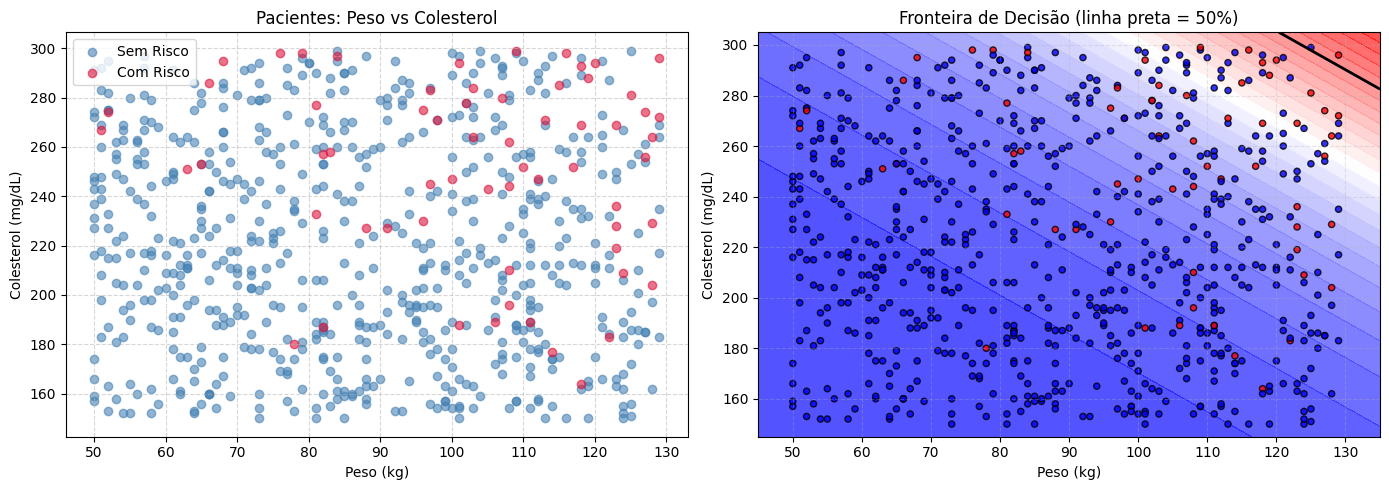

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


# 1. SIMULAR OS DADOS


np.random.seed(42)
N = 700

# Gerar peso e colesterol aleatórios
peso = np.random.randint(50, 130, size=N)
colesterol = np.random.randint(150, 300, size=N)


# 2. CALCULAR A PROBABILIDADE

# Fórmula do enunciado
z = 0.03 * peso + 0.02 * colesterol - 10
p = 1 / (1 + np.exp(-z))


# 3. GERAR A CLASSE Y

# 0 = sem risco | 1 = com risco

# Cria de forma aleatoria o rotulo de risco e sem risco de acordo com a probabilidade passada, tendo N amostras
y = np.random.binomial(n=1, p=p, size=N)

# 4. CRIAR TABELA COM OS DADOS


df = pd.DataFrame({
    "Peso_kg"      : peso,
    "Colesterol"   : colesterol,
    "Probabilidade": np.round(p, 4),
    "Risco"        : y
})

print(df.head())
print(f"\nSem risco: {(y == 0).sum()} | Com risco: {(y == 1).sum()}")


# 5. TREINAR O MODELO

X = df[["Peso_kg", "Colesterol"]].values
Y = df["Risco"].values

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 6. AVALIAR O MODELO


acuracia = np.mean(modelo.predict(X_test) == y_test) * 100
print(f"\nAcurácia: {acuracia:.1f}%")

print("Na vida real: dois pacientes com mesmo peso e colesterol podem ter resultados diferentes. O gráfico está correto e realista.")

# 7. GRÁFICOS


fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Distribuição dos pacientes ---
sem_risco = df[df["Risco"] == 0]
com_risco = df[df["Risco"] == 1]

axs[0].scatter(sem_risco["Peso_kg"], sem_risco["Colesterol"],
               alpha=0.6, color="steelblue", label="Sem Risco")
axs[0].scatter(com_risco["Peso_kg"], com_risco["Colesterol"],
               alpha=0.6, color="crimson", label="Com Risco")
axs[0].set_title("Pacientes: Peso vs Colesterol")
axs[0].set_xlabel("Peso (kg)")
axs[0].set_ylabel("Colesterol (mg/dL)")
axs[0].legend()
axs[0].grid(True, linestyle="--", alpha=0.5)

# --- Gráfico 2: Fronteira de decisão ---
xx, yy = np.meshgrid(np.linspace(45, 135, 300),
                     np.linspace(145, 305, 300))

grid  = np.c_[xx.ravel(), yy.ravel()]
probs = modelo.predict_proba(grid)[:, 1].reshape(xx.shape)

axs[1].contourf(xx, yy, probs, levels=25, alpha=0.7, cmap="bwr")
axs[1].scatter(X[:, 0], X[:, 1], c=Y, cmap="bwr", edgecolor="k", s=20, alpha=0.8)
axs[1].contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
axs[1].set_title("Fronteira de Decisão (linha preta = 50%)")
axs[1].set_xlabel("Peso (kg)")
axs[1].set_ylabel("Colesterol (mg/dL)")
axs[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
